In [31]:
%pip install scikit-learn
%pip install pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: c:\Users\hzizi\.pyenv\pyenv-win\versions\3.11.9\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: c:\Users\hzizi\.pyenv\pyenv-win\versions\3.11.9\python.exe -m pip install --upgrade pip


In [32]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: c:\Users\hzizi\.pyenv\pyenv-win\versions\3.11.9\python.exe -m pip install --upgrade pip


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [34]:
df = pd.read_csv('Crop_recommendation_extended.csv')

display(df.head())

,N,P,K,temperature,humidity,ph,rainfall,label
0,90.0,42.0,43.0,20.879744,82.002744,6.502985,202.935536,rice
1,85.0,58.0,41.0,21.770462,80.319644,7.038096,226.655537,rice
2,60.0,55.0,44.0,23.004459,82.320763,7.840207,263.964248,rice
3,74.0,35.0,40.0,26.491096,80.158363,6.980401,242.864034,rice
4,78.0,42.0,42.0,20.130175,81.604873,7.628473,262.717340,rice


In [35]:
display(df.size)
display(df.columns)
display(df.describe())

25600

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='str')

,N,P,K,temperature,humidity,ph,rainfall
count,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000,3200.000000
mean,54.661844,49.791625,52.290906,23.841408,69.825084,6.452933,112.984968
std,35.476584,29.172451,50.295611,6.661398,20.726493,0.818263,71.308550
min,0.000000,5.000000,5.000000,1.172029,14.258040,3.504752,20.211267
25%,24.875000,29.000000,22.500000,20.253438,57.022614,5.947336,63.270019
50%,47.750000,45.600000,37.500000,24.784676,74.362355,6.431795,93.521200
75%,86.000000,63.000000,52.000000,28.030332,87.011396,6.958392,139.779602
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [36]:
print("\nMissing Values:\n", df.isnull(). sum())


Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [38]:
X = df[['temperature', 'humidity', 'rainfall']]
y = df['label']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y , test_size=0.2, random_state = 42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state = 42, n_jobs=-1)

In [40]:
model.fit(X_train, y_train)
print("Model training complete\n")

Model training complete



In [41]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy * 100:.2f}%")


Model Accuracy: 79.22%


In [42]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       apple       0.70      0.95      0.81        20
      banana       1.00      0.90      0.95        20
      barley       0.55      0.60      0.57        20
   blackgram       0.94      0.80      0.86        20
    chickpea       1.00      1.00      1.00        20
     coconut       0.91      1.00      0.95        20
      coffee       0.95      0.95      0.95        20
      cotton       0.73      0.95      0.83        20
      grapes       0.94      0.80      0.86        20
        jute       0.91      1.00      0.95        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.73      0.95      0.83        20
       maize       0.45      0.95      0.61        20
       mango       0.95      1.00      0.98        20
   mothbeans       0.84      0.80      0.82        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
        oats       0.53    

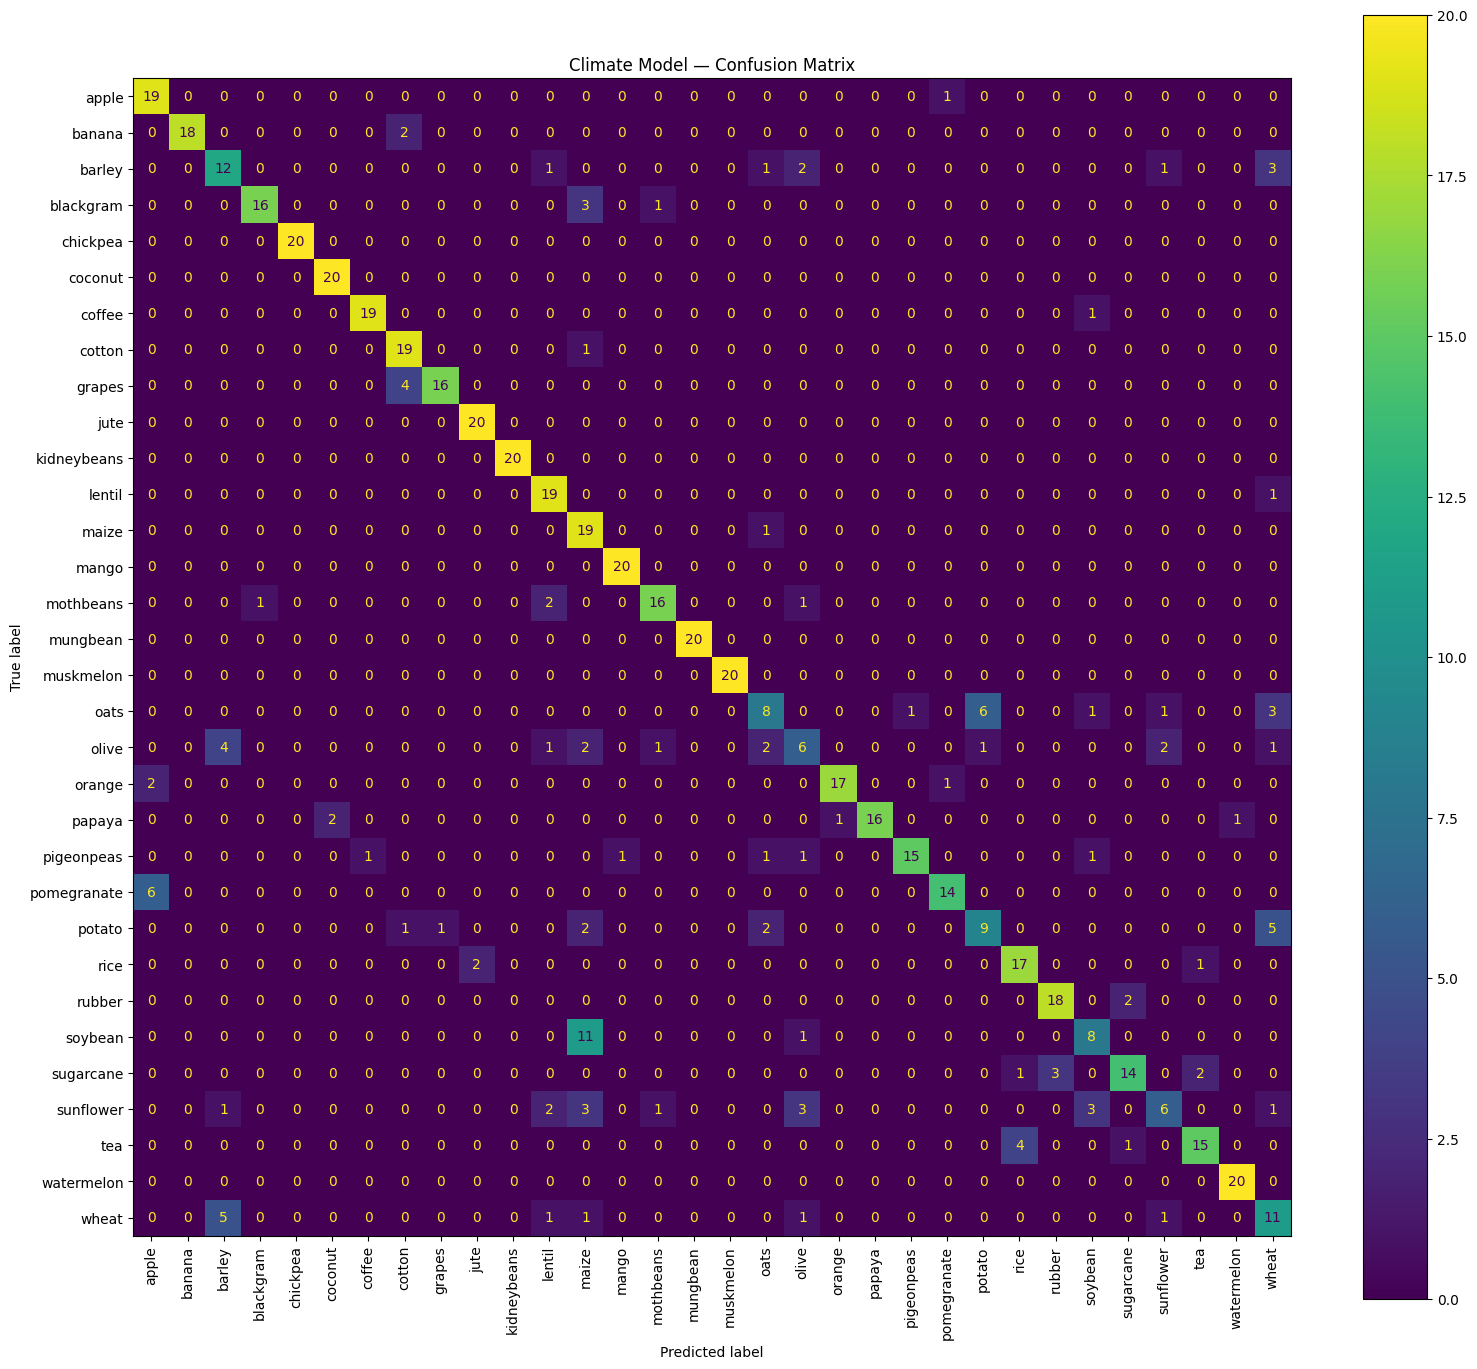

In [ ]:
# New cell — confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 14))
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, ax=ax, xticks_rotation=90)
plt.title("Climate Model - Confusion Matrix")
plt.tight_layout()
plt.show()

In [44]:
importances = model.feature_importances_
feature_names = X.columns

# Create a clean data frame and sort it
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importances:")
print(importance_df)

Feature Importances:
       Feature  Importance
2     rainfall    0.369816
1     humidity    0.355272
0  temperature    0.274911


In [45]:
sample_conditions = pd.DataFrame(
    [[28.5, 55.0, 300.0]], 
    columns=['temperature', 'humidity', 'rainfall']
)

In [46]:
predicted_crop = model.predict(sample_conditions)
print(f"Given these soil and weather conditions, the model recommends planting: {predicted_crop[0]}")

Given these soil and weather conditions, the model recommends planting: sugarcane


In [47]:
import joblib
import os

# 1. Export the model from memory into a physical file
joblib.dump(model, 'crop_model.joblib')

# 2. Find out exactly where on your computer this file was just saved
current_folder = os.getcwd()
print("Success! Your model is saved as a separate file in this exact folder:")
print(current_folder)

Success! Your model is saved as a separate file in this exact folder:
c:\Users\hzizi\OneDrive\Documents\Agri_AI_Project
